# HistoMap Tutorial: Integrating Cell Segmentation Data

## Introduction

This tutorial demonstrates how to integrate cell segmentation data with spatial transcriptomics in HistoMapTx. Cell segmentation provides information about individual cells' boundaries, allowing us to analyze cell density, morphology, and distribution across different tissue regions.

Key advantages of adding segmentation data:
- Quantify cell density in different tissue annotations
- Correlate cellular features with gene expression patterns
- Identify regions with abnormal cellular architecture

Let's get started!

## 1. Setting up the Environment

We'll start by loading our previously annotated HistoMap object.

In [1]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Import required libraries
import HistoMapTx as hm  # Main package for annotation integration

# Load the previously processed HistoMap object
histomap = hm.load_histomap("histomap_filtered_annotated_pickle")
print(histomap)

Object loaded from histomap_filtered_annotated_pickle
HistoMap Object

--------Annotation--------
📂 Annotation file used: /home/croizer/Téléchargements/QuPath-v0.5.1-Linux/Project1/AO5603_NIP_0085020_final.geojson.gz
📂 Full resolution image used: /home/croizer/Documents/Curie/ressources/4_visium_section/2_HGSOC/2_Run2_Geraldine/VISIUM2/images/AO5603_NIP_0085020.tiff
🔢 Number of annotations present: 6
🏷 Annotations: giant_cells, Necrosis, Tumor, Stroma, Negative, Positive
🏷 Activated annotations: Necrosis, giant_cells, Stroma, Tumor
🏷 Disabled annotations: Positive, Negative

-------Spatial Data--------
SpatialData object
├── Images
│     ├── 'AO1124_hires_image': DataArray[cyx] (3, 1970, 2000)
│     └── 'AO1124_lowres_image': DataArray[cyx] (3, 591, 600)
├── Shapes
│     └── 'AO1124': GeoDataFrame shape: (2773, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2773, 36601)
with coordinate systems:
    ▸ 'downscaled_hires', with elements:
        AO1124_hires_image (Images), AO1124 

## 2. Loading Cell Segmentation Data

Cell segmentation data is typically generated using specialized software like QuPath, CellPose, or HALO, which identifies individual cells in the histology image. HistoMapTx can import this data from GeoJSON files.

In [4]:
# Path to the cell segmentation file (GeoJSON format)
# Update this path to your own segmentation file
segmentation_file = "/home/croizer/Téléchargements/QuPath-v0.5.1-Linux/Project1/AO5603_NIP_0085020_all_segmentation.geojson.gz"

In [5]:
# Add cell segmentation data to the HistoMap object
# This function imports cell geometries and calculates which Visium spots each cell belongs to
histomap.add_segmentation(segmentation_file)

Segmentation added. Number of cells in the file :90763. Average cell per spot : 17.433465560764514


## 3. Visualizing Cell Distribution

Now that we've added cell segmentation data, we can visualize the distribution of cells across the tissue.

In [ ]:
# Plot individual cells on the tissue image
# This plot can be very dense with many cells, so it's commented out by default
# Uncomment to visualize all individual cells

#hm.plot_cells(histomap, alpha=0.5, size=5)

### 3.1 Analyzing Cell Density

Rather than plotting individual cells, we can visualize cell density per spot, which provides a clearer picture of cellular distribution across the tissue.

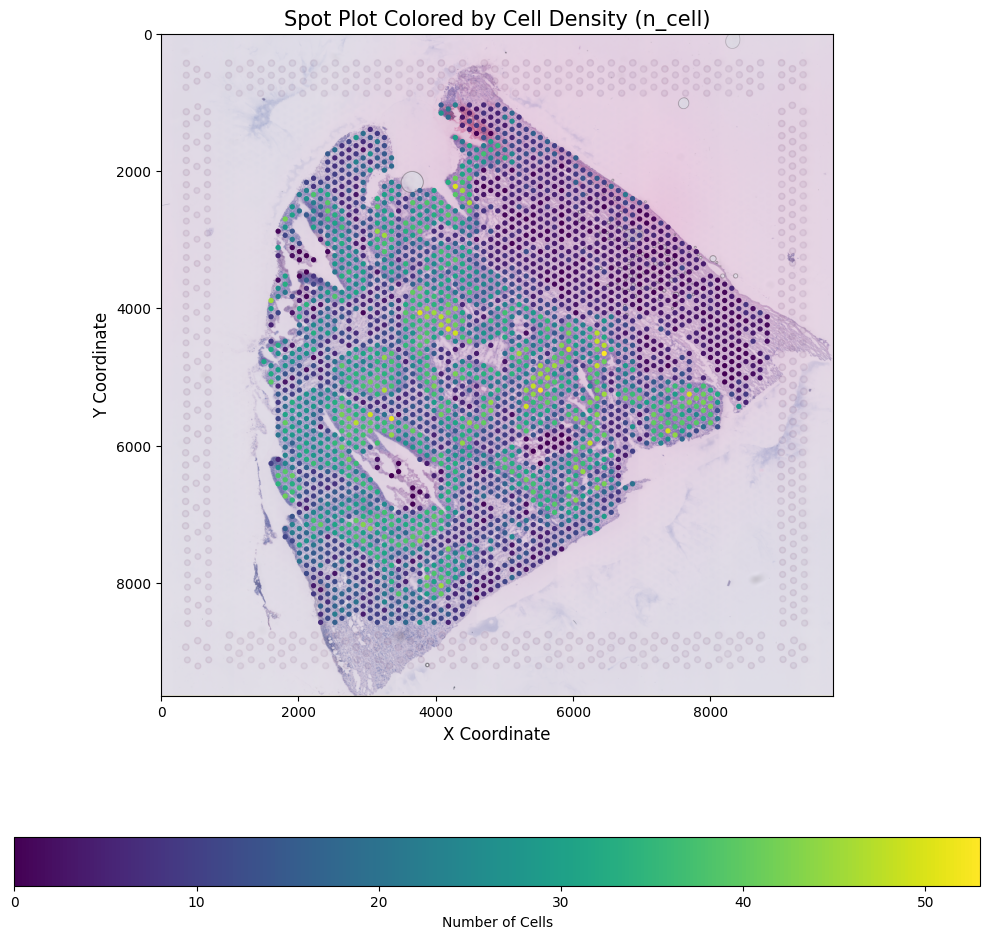

In [8]:
# Plot cell density (number of cells per spot) across the tissue
# Default visualization with automatic color scale
hm.plot_cell_density(histomap)

### 3.2 Adjusting Cell Density Visualization

If some spots have extremely high cell counts that skew the color scale, we can set a maximum cutoff value to improve visualization.

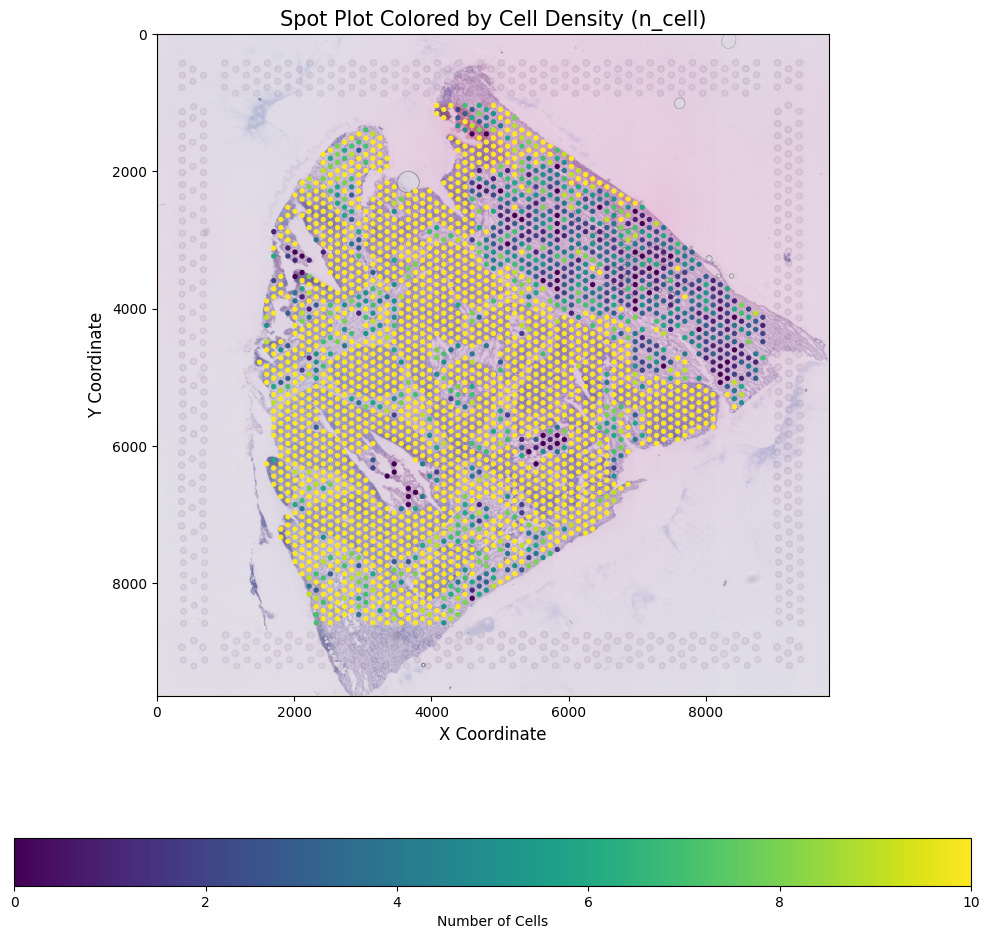

In [9]:
# Plot cell density with a maximum cutoff to prevent outliers from skewing the color scale
# Spots with more than 10 cells will be colored at the maximum intensity
hm.plot_cell_density(histomap, max_cutoff=10)

## 4. Integration with Gene Expression Data

One of the key benefits of adding cell segmentation is the ability to integrate cellular features with gene expression. Let's convert our HistoMap object to AnnData format for further analysis.

In [10]:
# Convert HistoMap object to AnnData format
# This includes cell count information in the observation metadata
adata = histomap.to_anndata()

### 4.1 Comparing Cell Density Across Tissue Annotations

A key question in tissue analysis is whether different regions (tumor, stroma, etc.) have different cellular densities. Let's visualize this.

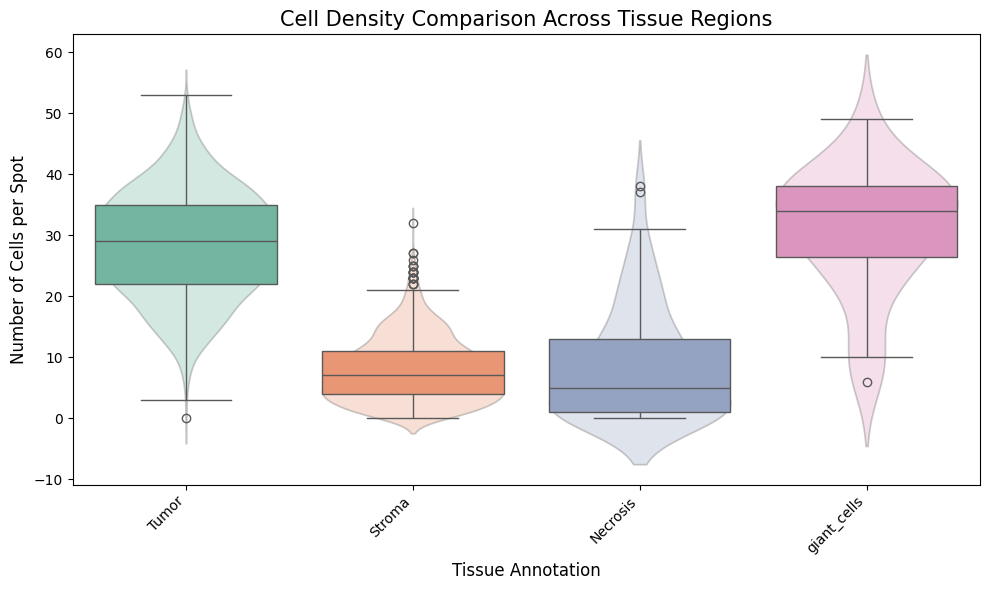

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns
# Create a combined violin+box plot to compare cell density across different tissue annotations
annotation_column = 'Annotation_map'
cell_column = 'n_cell'
plot_data = adata.obs[[annotation_column, cell_column]].copy()

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the violin plot for distribution visualization
sns.violinplot(x=annotation_column, y=cell_column, data=plot_data, 
               inner=None, palette='Set2', alpha=0.3)

# Overlay a boxplot for statistical visualization
sns.boxplot(x=annotation_column, y=cell_column, data=plot_data, palette='Set2')

# Enhance the plot with titles and labels
plt.title("Cell Density Comparison Across Tissue Regions", fontsize=15)
plt.xlabel("Tissue Annotation", fontsize=12)
plt.ylabel("Number of Cells per Spot", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate labels for better readability
plt.tight_layout()
plt.show()

## 5. Advanced Analysis Ideas

With cell segmentation data integrated, you can perform many advanced analyses:

1. **Correlation Analysis**: Find genes whose expression correlates with cell density
2. **Cell Morphology**: Import and analyze cell shape features across different regions
3. **Spatial Cell Patterns**: Identify regions with abnormal cell distribution patterns
4. **Cell Type Prediction**: Use gene expression to predict cell types in segmented cells

Here's a template for correlation analysis between gene expression and cell density:

In [14]:
# Example: Find genes that correlate with cell density

import scanpy as sc
import numpy as np

# Preprocess data
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Calculate correlation for each gene
correlations = []
gene_names = []

for gene in adata.var_names:
    corr = np.corrcoef(adata[:, gene].X.toarray().flatten(), adata.obs['n_cell'])[0, 1]
    correlations.append(corr)
    gene_names.append(gene)
    
# Create a DataFrame with results
import pandas as pd
corr_df = pd.DataFrame({'gene': gene_names, 'correlation': correlations})
corr_df = corr_df.sort_values('correlation', ascending=False)

# Display top positively and negatively correlated genes
print("Top positively correlated genes with cell density:")
print(corr_df.head(10))
print("\nTop negatively correlated genes with cell density:")
print(corr_df.tail(10))


Top positively correlated genes with cell density:
            gene  correlation
2893    MIR205HG     0.574072
25345    GOLGA8B     0.539380
18921      PGGHG     0.533185
6379   LINC02009     0.506278
60         CCNL2     0.490970
32604      ZNF83     0.490556
4801     TFCP2L1     0.483676
875       COL9A2     0.477028
35182    FAM118A     0.475185
35435      PDHA1     0.472444

Top negatively correlated genes with cell density:
             gene  correlation
36588  AC136352.2          NaN
36589  AC171558.3          NaN
36590  AC171558.1          NaN
36591  AC133551.1          NaN
36592  AC136612.1          NaN
36594  AC136616.3          NaN
36595  AC136616.2          NaN
36596  AC141272.1          NaN
36597  AC023491.2          NaN
36598  AC007325.1          NaN


## Conclusion

In this tutorial, we've learned how to integrate cell segmentation data with spatial transcriptomics using HistoMapTx. This integration enables deeper analysis of the relationship between cellular features and gene expression across different tissue regions.

Key takeaways:
- Cell segmentation adds valuable cellular information to spatial transcriptomics data
- Different tissue regions often have distinct cell density patterns
- The combination of cellular features and gene expression can reveal tissue biology that neither can show alone

For further analysis, consider exploring the relationship between cell morphology features, spatial gene expression patterns, and tissue annotations to gain deeper insights into tissue architecture and function.